PARTIE 1 : CHARGEMENT DES DONNÉES

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, 
    roc_curve, confusion_matrix, mean_squared_error, mean_absolute_error, 
    r2_score, silhouette_score, davies_bouldin_score
)

# Classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier, XGBRegressor

# Régression
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Clustering
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

# Time Series
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

print("="*70)
print("PROJET BI - MACHINE LEARNING")
print("="*70)

# ============================================
# 2. CONNEXION À SQL SERVER
# ============================================

server = 'localhost'
database = 'event_DWH'

connection_string = f"mssql+pyodbc://@{server}/{database}?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes"
engine = create_engine(connection_string)

# Test de connexion
with engine.connect() as conn:
    result = conn.execute(text("SELECT 1"))
    print("✅ Connexion réussie")

# ============================================
# 3. CHARGEMENT DES DONNÉES BRUTES (df_raw)
# ============================================

query = """
SELECT 
    f.id_reservation,
    f.price,
    f.nbr_reservations,
    f.nbr_visitors,
    f.marketing_spend,
    f.market_count,
    f.status as reservation_status,
    e.type as event_type,
    e.event_date,
    cat.name as category_name,
    l.city,
    l.country,
    ev.rating,
    t.trend_score,
    t.growth_rate_pct,
    v.capacity_min,
    v.capacity_max,
    v.venue_type
FROM FACT_VENTES f
LEFT JOIN Dim_Event e ON f.id_event = e.id_event
LEFT JOIN Dim_Category cat ON f.id_category = cat.id_category
LEFT JOIN Dim_Localisation l ON f.id_localisation = l.id_localisation
LEFT JOIN Dim_Evaluation ev ON f.id_evaluation = ev.id_evaluation
LEFT JOIN Dim_Trends t ON f.id_trend = t.id_trend
LEFT JOIN Dim_Venue v ON f.id_venue = v.id_venue
"""

df_raw = pd.read_sql(query, engine)
print(f"✅ Données chargées: {df_raw.shape[0]} lignes, {df_raw.shape[1]} colonnes")

# Sauvegarde
df_raw.to_csv('event_data.csv', index=False)
print("✅ Données sauvegardées dans 'event_data.csv'")

PROJET BI - MACHINE LEARNING
✅ Connexion réussie
✅ Données chargées: 4480 lignes, 18 colonnes
✅ Données sauvegardées dans 'event_data.csv'


PARTIE 2 : DATA PREPARATION

In [3]:
print("\n" + "="*70)
print("DATA PREPARATION")
print("="*70)

# ============================================
# 4.1 SUPPRESSION DES COLONNES ID
# ============================================

id_columns = ['id_reservation']
df = df_raw.drop(columns=[col for col in id_columns if col in df_raw.columns])
print(f"Colonnes ID supprimées: {id_columns}")

# ============================================
# 4.2 TRAITEMENT DES VALEURS MANQUANTES
# ============================================

# Colonnes numériques : remplacer par la médiane
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)
        print(f"  {col}: rempli avec la médiane")

# Colonnes catégorielles : remplacer par le mode
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()
        df[col].fillna(mode_val[0] if not mode_val.empty else "Inconnu", inplace=True)
        print(f"  {col}: rempli avec le mode")

print("✅ Valeurs manquantes traitées")

# ============================================
# 4.3 ENCODAGE DES VARIABLES CATÉGORIELLES
# ============================================

label_encoders = {}
categorical_to_encode = ['event_type', 'category_name', 'city', 'country', 'venue_type', 'reservation_status']

for col in categorical_to_encode:
    if col in df.columns:
        le = LabelEncoder()
        df[col] = df[col].fillna('Inconnu')
        df[f'{col}_encoded'] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le
        print(f"Encodage: {col} → {col}_encoded ({len(le.classes_)} catégories)")

# ============================================
# 4.4 FEATURE ENGINEERING (AMÉLIORÉ)
# ============================================

print("\nFeature Engineering:")

# Ratios pertinents
df['marketing_per_visitor'] = df['marketing_spend'] / (df['nbr_visitors'] + 1)
df['price_per_reservation'] = df['price'] / (df['nbr_reservations'] + 1)
df['visitors_per_reservation'] = df['nbr_visitors'] / (df['nbr_reservations'] + 1)
df['conversion_rate'] = df['nbr_reservations'] / (df['nbr_visitors'] + 1) * 100
print("  - marketing_per_visitor, price_per_reservation, visitors_per_reservation, conversion_rate")

# Features temporelles
df['event_date'] = pd.to_datetime(df['event_date'])
df['month'] = df['event_date'].dt.month
df['quarter'] = df['event_date'].dt.quarter
df['year'] = df['event_date'].dt.year
df['day_of_week'] = df['event_date'].dt.dayofweek
print("  - month, quarter, year, day_of_week")

# Saison
df['season'] = df['month'].apply(lambda x: 'Hiver' if x in [12,1,2] else 
                                          'Printemps' if x in [3,4,5] else
                                          'Été' if x in [6,7,8] else 'Automne')
df['season_encoded'] = df['season'].map({'Hiver':0, 'Printemps':1, 'Été':2, 'Automne':3})
print("  - season, season_encoded")

# ============================================
# 4.5 SUPPRESSION DES COLONNES NON UTILISÉES
# ============================================

columns_to_drop = ['event_date', 'season', 'reservation_status', 'category_name', 
                   'city', 'country', 'venue_type', 'comment']

columns_to_drop = [col for col in columns_to_drop if col in df.columns]
df = df.drop(columns=columns_to_drop)
print(f"Colonnes supprimées: {columns_to_drop}")

# ============================================
# 4.6 SAUVEGARDE
# ============================================

df.to_csv('data_cleaned.csv', index=False)

print(f"\n✅ Data preparation terminée")
print(f"   Dataset nettoyé: {df.shape[0]} lignes, {df.shape[1]} colonnes")
print(f"   Fichier sauvegardé: data_cleaned.csv")

print("\nAperçu des données nettoyées:")
print(df.head())


DATA PREPARATION
Colonnes ID supprimées: ['id_reservation']
✅ Valeurs manquantes traitées
Encodage: event_type → event_type_encoded (3 catégories)
Encodage: category_name → category_name_encoded (3 catégories)
Encodage: city → city_encoded (18 catégories)
Encodage: country → country_encoded (1 catégories)
Encodage: venue_type → venue_type_encoded (2 catégories)
Encodage: reservation_status → reservation_status_encoded (3 catégories)

Feature Engineering:
  - marketing_per_visitor, price_per_reservation, visitors_per_reservation, conversion_rate
  - month, quarter, year, day_of_week
  - season, season_encoded
Colonnes supprimées: ['event_date', 'season', 'reservation_status', 'category_name', 'city', 'country', 'venue_type']

✅ Data preparation terminée
   Dataset nettoyé: 4480 lignes, 26 colonnes
   Fichier sauvegardé: data_cleaned.csv

Aperçu des données nettoyées:
     price  nbr_reservations  nbr_visitors  marketing_spend  market_count  \
0   8478.0               155            66 

In [4]:
# Cellule : Statistiques sur les colonnes numériques (sans les ID)
print("📊 Statistiques des colonnes numériques (sans ID):")
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(f"Colonnes numériques analysées: {numeric_cols.tolist()}")
print("\n")
df[numeric_cols].describe()

📊 Statistiques des colonnes numériques (sans ID):
Colonnes numériques analysées: ['price', 'nbr_reservations', 'nbr_visitors', 'marketing_spend', 'market_count', 'rating', 'trend_score', 'growth_rate_pct', 'capacity_min', 'capacity_max', 'event_type_encoded', 'category_name_encoded', 'city_encoded', 'country_encoded', 'venue_type_encoded', 'reservation_status_encoded', 'marketing_per_visitor', 'price_per_reservation', 'visitors_per_reservation', 'conversion_rate', 'season_encoded']




,price,nbr_reservations,nbr_visitors,marketing_spend,market_count,rating,trend_score,growth_rate_pct,capacity_min,capacity_max,...,category_name_encoded,city_encoded,country_encoded,venue_type_encoded,reservation_status_encoded,marketing_per_visitor,price_per_reservation,visitors_per_reservation,conversion_rate,season_encoded
count,4480.000000,4480.000000,4480.000000,4480.000000,4480.000000,4480.000000,4480.0,4480.0,4480.000000,4480.000000,...,4480.000000,4480.000000,4480.0,4480.000000,4480.000000,4480.000000,4480.000000,4480.000000,4480.000000,4480.000000
mean,9952.545982,200.819643,4107.979911,19877.678571,6.592634,3.053795,0.0,0.0,210.446429,395.156250,...,1.253571,8.445312,0.0,0.606027,0.992857,33.763187,62.439098,23.642919,29.234537,1.502679
std,15480.157118,61.861508,5726.600066,4451.644585,6.025020,1.429604,0.0,0.0,75.499538,117.411323,...,0.825734,5.177980,0.0,0.488684,0.814549,82.759106,140.340274,28.507438,62.601385,1.115357
min,201.000000,42.000000,66.000000,12000.000000,0.000000,1.000000,0.0,0.0,100.000000,200.000000,...,0.000000,0.000000,0.0,0.000000,0.000000,0.540151,0.695652,0.423077,1.120814,0.000000
25%,3888.000000,176.000000,1258.000000,17000.000000,1.000000,2.000000,0.0,0.0,200.000000,400.000000,...,1.000000,4.000000,0.0,0.000000,0.000000,4.875670,19.313127,6.166667,4.806117,1.000000
50%,7831.500000,203.000000,1983.000000,21000.000000,5.000000,3.000000,0.0,0.0,200.000000,400.000000,...,1.000000,8.000000,0.0,1.000000,1.000000,7.458048,38.896078,9.768473,10.181452,2.000000
75%,11699.250000,239.000000,3661.000000,24000.000000,10.000000,4.000000,0.0,0.0,300.000000,500.000000,...,2.000000,13.000000,0.0,1.000000,2.000000,15.537601,59.053953,20.683616,16.123908,2.000000
max,149610.000000,298.000000,22215.000000,26000.000000,20.000000,5.000000,0.0,0.0,300.000000,500.000000,...,2.000000,17.000000,0.0,1.000000,2.000000,388.059701,3378.837209,88.860000,231.343284,3.000000


In [5]:
# Cellule : Voir les colonnes restantes
print("📋 Toutes les colonnes après nettoyage:")
for i, col in enumerate(df.columns):
    print(f"   {i+1}. {col} ({df[col].dtype})")

📋 Toutes les colonnes après nettoyage:
   1. price (float64)
   2. nbr_reservations (int64)
   3. nbr_visitors (int64)
   4. marketing_spend (float64)
   5. market_count (int64)
   6. event_type (object)
   7. rating (int64)
   8. trend_score (float64)
   9. growth_rate_pct (float64)
   10. capacity_min (int64)
   11. capacity_max (int64)
   12. event_type_encoded (int64)
   13. category_name_encoded (int64)
   14. city_encoded (int64)
   15. country_encoded (int64)
   16. venue_type_encoded (int64)
   17. reservation_status_encoded (int64)
   18. marketing_per_visitor (float64)
   19. price_per_reservation (float64)
   20. visitors_per_reservation (float64)
   21. conversion_rate (float64)
   22. month (int32)
   23. quarter (int32)
   24. year (int32)
   25. day_of_week (int32)
   26. season_encoded (int64)


In [6]:
# Cellule : Valeurs manquantes sur le DataFrame nettoyé
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Manquantes': missing, 'Pourcentage': missing_pct})
missing_df = missing_df[missing_df['Manquantes'] > 0].sort_values('Pourcentage', ascending=False)

print("🔍 Valeurs manquantes après nettoyage:")
if len(missing_df) > 0:
    print(missing_df)
else:
    print("✅ Aucune valeur manquante !")

🔍 Valeurs manquantes après nettoyage:
✅ Aucune valeur manquante !


In [7]:
# Cellule : Distribution des réservations
print("📈 Distribution du nombre de réservations:")
print(df['nbr_reservations'].describe())

# Créer la target (client fidèle = plus de 2 réservations)
df['target_fidele'] = (df['nbr_reservations'] > 2).astype(int)
print(f"\n🎯 Clients fidèles (target=1): {df['target_fidele'].sum():.0f}")
print(f"   Clients non fidèles (target=0): {(df['target_fidele'] == 0).sum():.0f}")
print(f"   Taux de fidélité: {df['target_fidele'].mean()*100:.1f}%")

📈 Distribution du nombre de réservations:
count    4480.000000
mean      200.819643
std        61.861508
min        42.000000
25%       176.000000
50%       203.000000
75%       239.000000
max       298.000000
Name: nbr_reservations, dtype: float64

🎯 Clients fidèles (target=1): 4480
   Clients non fidèles (target=0): 0
   Taux de fidélité: 100.0%


PARTIE 3 : CLASSIFICATION


PARTIE 3 : CLASSIFICATION - FIDELITE CLIENT (TOP 25%)
Seuil (75eme percentile): 239.00 reservations
Clients fideles: 1119 (25.0%)
Clients non fideles: 3361 (75.0%)

--------------------------------------------------
DECISION TREE
--------------------------------------------------
Accuracy:  0.6105
Precision: 0.2642
Recall:    0.3125
F1-Score:  0.2863
AUC-ROC:   0.5197

--------------------------------------------------
RANDOM FOREST
--------------------------------------------------
Accuracy:  0.6350
Precision: 0.2359
Recall:    0.2054
F1-Score:  0.2196
AUC-ROC:   0.5078


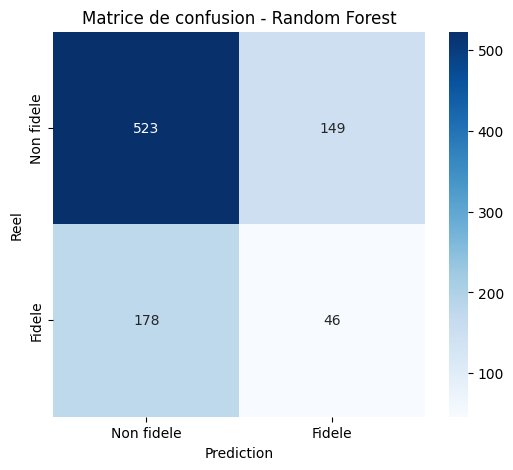

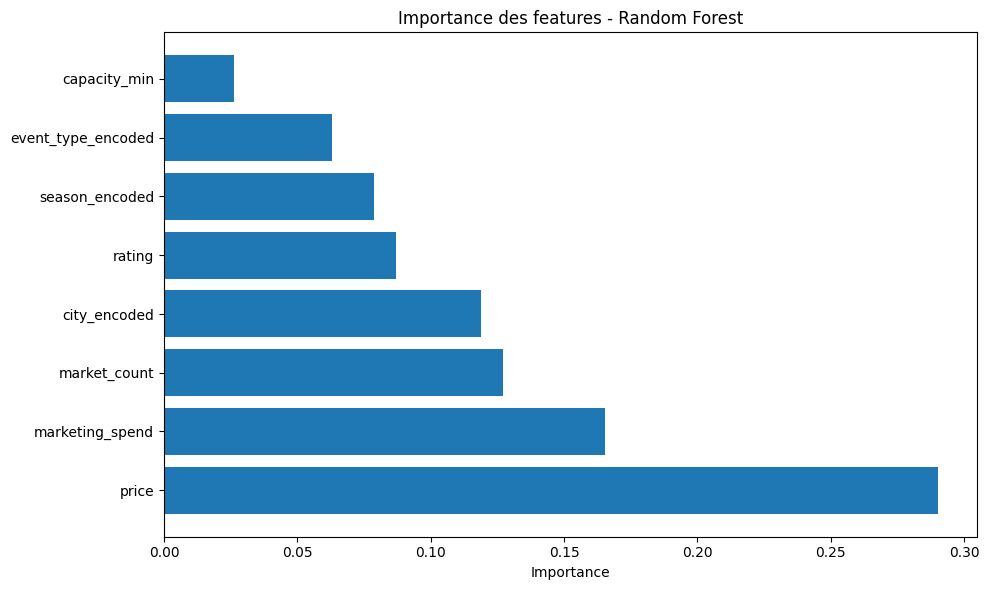


Top 5 features:
   price: 0.2904
   marketing_spend: 0.1654
   market_count: 0.1270
   city_encoded: 0.1190
   rating: 0.0869

--------------------------------------------------
XGBOOST
--------------------------------------------------
Accuracy:  0.5614
Precision: 0.2551
Recall:    0.3929
F1-Score:  0.3093
AUC-ROC:   0.5209

--------------------------------------------------
SVM
--------------------------------------------------
Accuracy:  0.5078
Precision: 0.2459
Recall:    0.4688
F1-Score:  0.3226
AUC-ROC:   0.4834

--------------------------------------------------
COURBES ROC COMPARATIVES
--------------------------------------------------


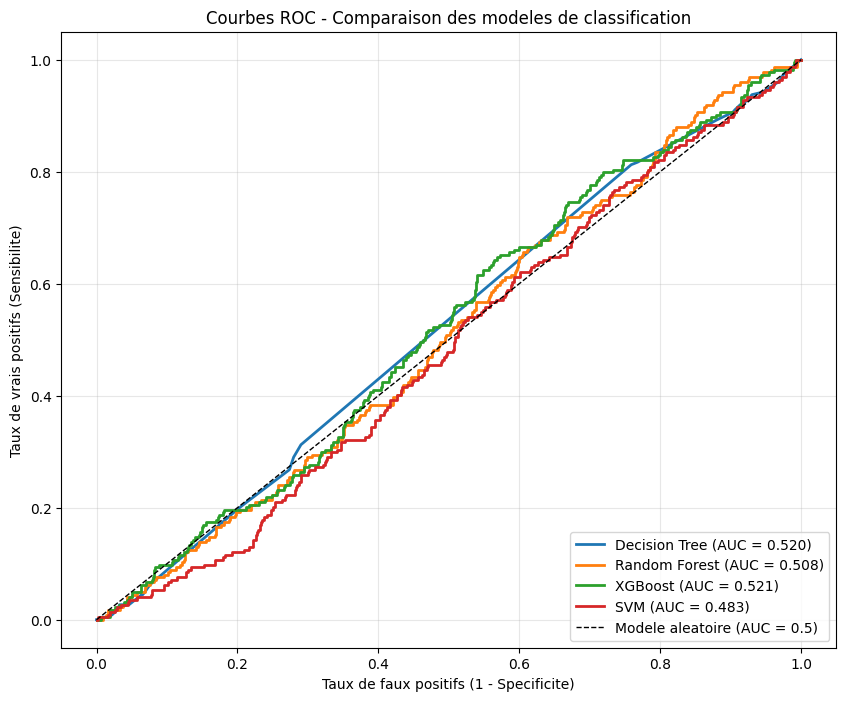


COMPARAISON DES 4 MODELES
       Modele  Accuracy  Precision   Recall       F1  AUC-ROC
Decision Tree  0.610491   0.264151 0.312500 0.286299 0.519694
Random Forest  0.635045   0.235897 0.205357 0.219570 0.507846
      XGBoost  0.561384   0.255072 0.392857 0.309315 0.520926
          SVM  0.507812   0.245902 0.468750 0.322581 0.483438

Meilleur modele: XGBoost (AUC-ROC = 0.5209)

CLASSIFICATION TERMINEE


In [8]:
print("\n" + "="*70)
print("PARTIE 3 : CLASSIFICATION - FIDELITE CLIENT (TOP 25%)")
print("="*70)

df = pd.read_csv('data_cleaned.csv')

seuil_fidelite = df['nbr_reservations'].quantile(0.75)
df['target_fidele'] = (df['nbr_reservations'] > seuil_fidelite).astype(int)

print(f"Seuil (75eme percentile): {seuil_fidelite:.2f} reservations")
print(f"Clients fideles: {df['target_fidele'].sum()} ({df['target_fidele'].mean()*100:.1f}%)")
print(f"Clients non fideles: {(df['target_fidele']==0).sum()} ({100-df['target_fidele'].mean()*100:.1f}%)")

features = [
    'price', 'marketing_spend', 'market_count',
    'rating', 'trend_score', 'growth_rate_pct',
    'capacity_min', 'capacity_max',
    'season_encoded', 'event_type_encoded', 
    'venue_type_encoded', 'city_encoded'
]

X = df[features].copy()
y = df['target_fidele'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n" + "-"*50)
print("DECISION TREE")
print("-"*50)

dt = DecisionTreeClassifier(
    max_depth=6,
    min_samples_split=15,
    min_samples_leaf=8,
    class_weight='balanced',
    random_state=42
)
dt.fit(X_train_scaled, y_train)

y_pred_dt = dt.predict(X_test_scaled)
y_proba_dt = dt.predict_proba(X_test_scaled)[:, 1]

print(f"Accuracy:  {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dt):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_dt):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_dt):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_proba_dt):.4f}")

print("\n" + "-"*50)
print("RANDOM FOREST")
print("-"*50)

rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=10,
    min_samples_split=15,
    min_samples_leaf=8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)
y_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]

print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_rf):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_proba_rf):.4f}")

cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non fidele', 'Fidele'],
            yticklabels=['Non fidele', 'Fidele'])
plt.title('Matrice de confusion - Random Forest')
plt.xlabel('Prediction')
plt.ylabel('Reel')
plt.savefig('confusion_matrix_rf.png', dpi=300)
plt.show()

importance = pd.DataFrame({
    'feature': features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(importance['feature'][:8], importance['importance'][:8])
plt.xlabel('Importance')
plt.title('Importance des features - Random Forest')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300)
plt.show()

print("\nTop 5 features:")
for i, row in importance.head(5).iterrows():
    print(f"   {row['feature']}: {row['importance']:.4f}")

print("\n" + "-"*50)
print("XGBOOST")
print("-"*50)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=60,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)
xgb.fit(X_train_scaled, y_train)

y_pred_xgb = xgb.predict(X_test_scaled)
y_proba_xgb = xgb.predict_proba(X_test_scaled)[:, 1]

print(f"Accuracy:  {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_xgb):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_proba_xgb):.4f}")

print("\n" + "-"*50)
print("SVM")
print("-"*50)

svm = SVC(
    C=0.8,
    kernel='rbf',
    gamma='scale',
    class_weight='balanced',
    probability=True,
    random_state=42
)
svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)
y_proba_svm = svm.predict_proba(X_test_scaled)[:, 1]

print(f"Accuracy:  {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_svm):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_svm):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_svm):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_proba_svm):.4f}")

print("\n" + "-"*50)
print("COURBES ROC COMPARATIVES")
print("-"*50)

plt.figure(figsize=(10, 8))

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)
auc_dt = roc_auc_score(y_test, y_proba_dt)
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.3f})', linewidth=2)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
auc_rf = roc_auc_score(y_test, y_proba_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})', linewidth=2)

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
auc_xgb = roc_auc_score(y_test, y_proba_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.3f})', linewidth=2)

fpr_svm, tpr_svm, _ = roc_curve(y_test, y_proba_svm)
auc_svm = roc_auc_score(y_test, y_proba_svm)
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {auc_svm:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Modele aleatoire (AUC = 0.5)', linewidth=1)
plt.xlabel('Taux de faux positifs (1 - Specificite)')
plt.ylabel('Taux de vrais positifs (Sensibilite)')
plt.title('Courbes ROC - Comparaison des modeles de classification')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.savefig('roc_curves.png', dpi=300)
plt.show()

print("\n" + "="*70)
print("COMPARAISON DES 4 MODELES")
print("="*70)

results = pd.DataFrame([
    {'Modele': 'Decision Tree', 'Accuracy': accuracy_score(y_test, y_pred_dt),
     'Precision': precision_score(y_test, y_pred_dt), 'Recall': recall_score(y_test, y_pred_dt),
     'F1': f1_score(y_test, y_pred_dt), 'AUC-ROC': roc_auc_score(y_test, y_proba_dt)},
    {'Modele': 'Random Forest', 'Accuracy': accuracy_score(y_test, y_pred_rf),
     'Precision': precision_score(y_test, y_pred_rf), 'Recall': recall_score(y_test, y_pred_rf),
     'F1': f1_score(y_test, y_pred_rf), 'AUC-ROC': roc_auc_score(y_test, y_proba_rf)},
    {'Modele': 'XGBoost', 'Accuracy': accuracy_score(y_test, y_pred_xgb),
     'Precision': precision_score(y_test, y_pred_xgb), 'Recall': recall_score(y_test, y_pred_xgb),
     'F1': f1_score(y_test, y_pred_xgb), 'AUC-ROC': roc_auc_score(y_test, y_proba_xgb)},
    {'Modele': 'SVM', 'Accuracy': accuracy_score(y_test, y_pred_svm),
     'Precision': precision_score(y_test, y_pred_svm), 'Recall': recall_score(y_test, y_pred_svm),
     'F1': f1_score(y_test, y_pred_svm), 'AUC-ROC': roc_auc_score(y_test, y_proba_svm)}
])

print(results.to_string(index=False))

best = results.loc[results['AUC-ROC'].idxmax(), 'Modele']
best_auc = results['AUC-ROC'].max()

print(f"\nMeilleur modele: {best} (AUC-ROC = {best_auc:.4f})")

print("\n" + "="*70)
print("CLASSIFICATION TERMINEE")
print("="*70)

PARTIE 4 : RÉGRESSION


PARTIE 4 : REGRESSION - PREDICTION DU PRIX
Features utilisees (13):
   - market_count
   - nbr_visitors
   - nbr_reservations
   - marketing_spend
   - rating
   - trend_score
   - growth_rate_pct
   - capacity_min
   - capacity_max
   - season_encoded
   - event_type_encoded
   - venue_type_encoded
   - city_encoded

--------------------------------------------------
4.1 REGRESSION LINEAIRE
--------------------------------------------------
RMSE: 17688.01
MAE: 6817.72
R²: -0.0056


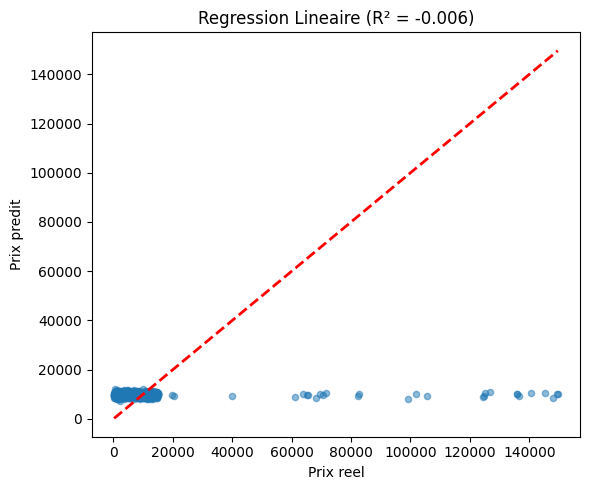


--------------------------------------------------
4.2 RANDOM FOREST REGRESSOR
--------------------------------------------------
RMSE: 17849.65
MAE: 7269.50
R²: -0.0240


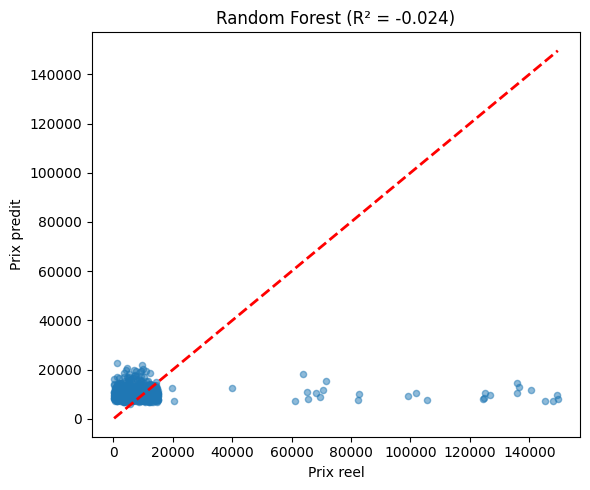

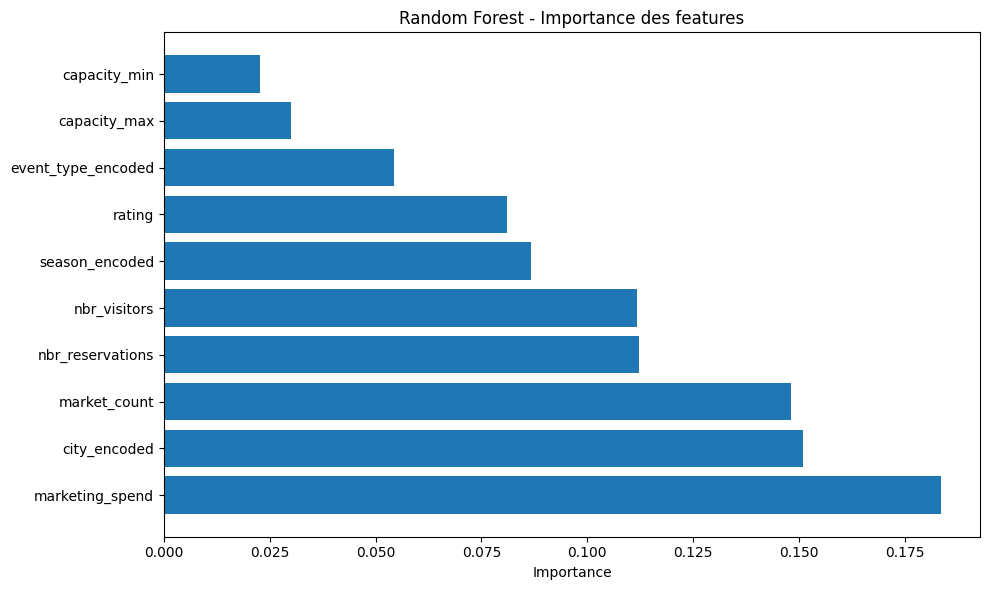


Top 5 features:
   marketing_spend: 0.1836
   city_encoded: 0.1510
   market_count: 0.1482
   nbr_reservations: 0.1121
   nbr_visitors: 0.1117

--------------------------------------------------
4.3 XGBOOST REGRESSOR
--------------------------------------------------
RMSE: 17991.28
MAE: 7421.58
R²: -0.0404


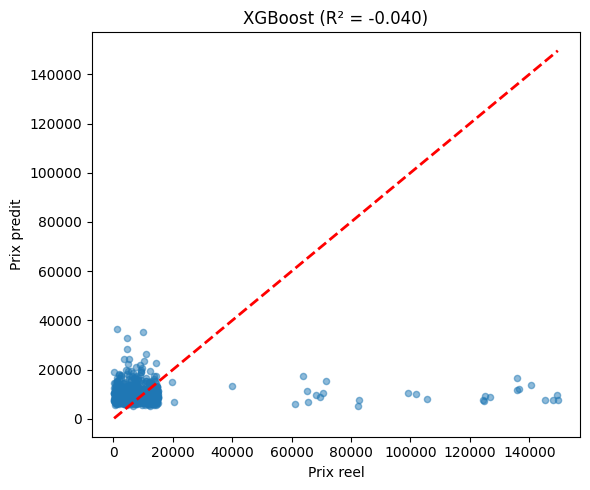


--------------------------------------------------
COMPARAISON DES 3 MODELES
--------------------------------------------------
             Modele         RMSE         MAE        R²
Regression Lineaire 17688.011911 6817.719235 -0.005574
      Random Forest 17849.654371 7269.495904 -0.024037
            XGBoost 17991.283517 7421.576021 -0.040352

Meilleur modele: Regression Lineaire (R² = -0.0056)

--------------------------------------------------
VISUALISATION COMPARATIVE
--------------------------------------------------


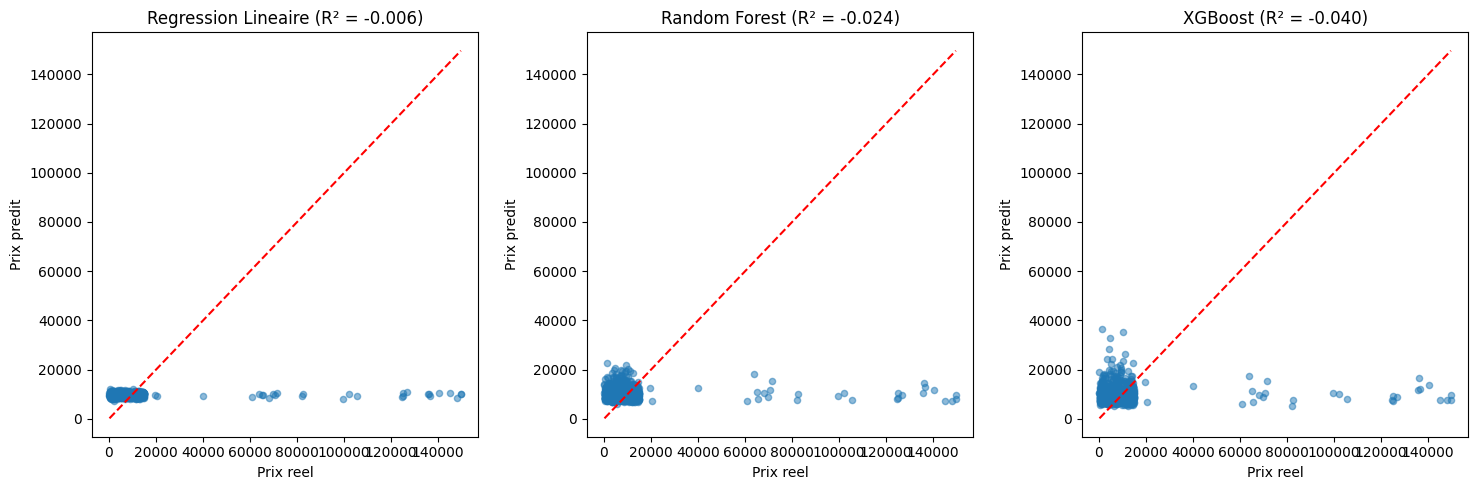


REGRESSION TERMINEE


In [9]:
print("\n" + "="*70)
print("PARTIE 4 : REGRESSION - PREDICTION DU PRIX")
print("="*70)

df = pd.read_csv('data_cleaned.csv')

features = [
    'market_count',
    'nbr_visitors', 
    'nbr_reservations',
    'marketing_spend',
    'rating',
    'trend_score',
    'growth_rate_pct',
    'capacity_min',
    'capacity_max',
    'season_encoded',
    'event_type_encoded',
    'venue_type_encoded',
    'city_encoded'
]

print(f"Features utilisees ({len(features)}):")
for f in features:
    print(f"   - {f}")

X = df[features].copy()
y = df['price'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n" + "-"*50)
print("4.1 REGRESSION LINEAIRE")
print("-"*50)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"RMSE: {rmse_lr:.2f}")
print(f"MAE: {mae_lr:.2f}")
print(f"R²: {r2_lr:.4f}")

plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred_lr, alpha=0.5, s=20)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Prix reel')
plt.ylabel('Prix predit')
plt.title(f'Regression Lineaire (R² = {r2_lr:.3f})')
plt.tight_layout()
plt.savefig('reg_linear.png', dpi=300)
plt.show()

print("\n" + "-"*50)
print("4.2 RANDOM FOREST REGRESSOR")
print("-"*50)

rf_reg = RandomForestRegressor(
    n_estimators=150,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)
rf_reg.fit(X_train_scaled, y_train)

y_pred_rf = rf_reg.predict(X_test_scaled)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"RMSE: {rmse_rf:.2f}")
print(f"MAE: {mae_rf:.2f}")
print(f"R²: {r2_rf:.4f}")

plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred_rf, alpha=0.5, s=20)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Prix reel')
plt.ylabel('Prix predit')
plt.title(f'Random Forest (R² = {r2_rf:.3f})')
plt.tight_layout()
plt.savefig('reg_rf.png', dpi=300)
plt.show()

importance = pd.DataFrame({
    'feature': features,
    'importance': rf_reg.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(importance['feature'][:10], importance['importance'][:10])
plt.xlabel('Importance')
plt.title('Random Forest - Importance des features')
plt.tight_layout()
plt.savefig('reg_rf_importance.png', dpi=300)
plt.show()

print("\nTop 5 features:")
for i, row in importance.head(5).iterrows():
    print(f"   {row['feature']}: {row['importance']:.4f}")

print("\n" + "-"*50)
print("4.3 XGBOOST REGRESSOR")
print("-"*50)

xgb_reg = XGBRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42
)
xgb_reg.fit(X_train_scaled, y_train)

y_pred_xgb = xgb_reg.predict(X_test_scaled)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"RMSE: {rmse_xgb:.2f}")
print(f"MAE: {mae_xgb:.2f}")
print(f"R²: {r2_xgb:.4f}")

plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred_xgb, alpha=0.5, s=20)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Prix reel')
plt.ylabel('Prix predit')
plt.title(f'XGBoost (R² = {r2_xgb:.3f})')
plt.tight_layout()
plt.savefig('reg_xgb.png', dpi=300)
plt.show()

print("\n" + "-"*50)
print("COMPARAISON DES 3 MODELES")
print("-"*50)

results_reg = pd.DataFrame([
    {'Modele': 'Regression Lineaire', 'RMSE': rmse_lr, 'MAE': mae_lr, 'R²': r2_lr},
    {'Modele': 'Random Forest', 'RMSE': rmse_rf, 'MAE': mae_rf, 'R²': r2_rf},
    {'Modele': 'XGBoost', 'RMSE': rmse_xgb, 'MAE': mae_xgb, 'R²': r2_xgb}
])

print(results_reg.to_string(index=False))

best_r2 = results_reg.loc[results_reg['R²'].idxmax(), 'Modele']
best_r2_value = results_reg['R²'].max()

print(f"\nMeilleur modele: {best_r2} (R² = {best_r2_value:.4f})")

print("\n" + "-"*50)
print("VISUALISATION COMPARATIVE")
print("-"*50)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].scatter(y_test, y_pred_lr, alpha=0.5, s=20)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_xlabel('Prix reel')
axes[0].set_ylabel('Prix predit')
axes[0].set_title(f'Regression Lineaire (R² = {r2_lr:.3f})')

axes[1].scatter(y_test, y_pred_rf, alpha=0.5, s=20)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1].set_xlabel('Prix reel')
axes[1].set_ylabel('Prix predit')
axes[1].set_title(f'Random Forest (R² = {r2_rf:.3f})')

axes[2].scatter(y_test, y_pred_xgb, alpha=0.5, s=20)
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[2].set_xlabel('Prix reel')
axes[2].set_ylabel('Prix predit')
axes[2].set_title(f'XGBoost (R² = {r2_xgb:.3f})')

plt.tight_layout()
plt.savefig('reg_comparison.png', dpi=300)
plt.show()

print("\n" + "="*70)
print("REGRESSION TERMINEE")
print("="*70)

PARTIE 5 : CLUSTERING

📊 CLUSTERING - Segmentation des villes
📁 Dataset chargé

📊 Données agrégées: 18 villes

📋 Features utilisées (7): ['nb_events', 'avg_price', 'avg_reservations', 'avg_visitors', 'avg_marketing', 'avg_rating', 'avg_trend']
📊 Shape: (18, 7)

🔍 Recherche du nombre optimal de clusters (K-Means)
K=2 → Inertie=77, Silhouette=0.257
K=3 → Inertie=60, Silhouette=0.212
K=4 → Inertie=48, Silhouette=0.215
K=5 → Inertie=41, Silhouette=0.196
K=6 → Inertie=34, Silhouette=0.237
K=7 → Inertie=25, Silhouette=0.291


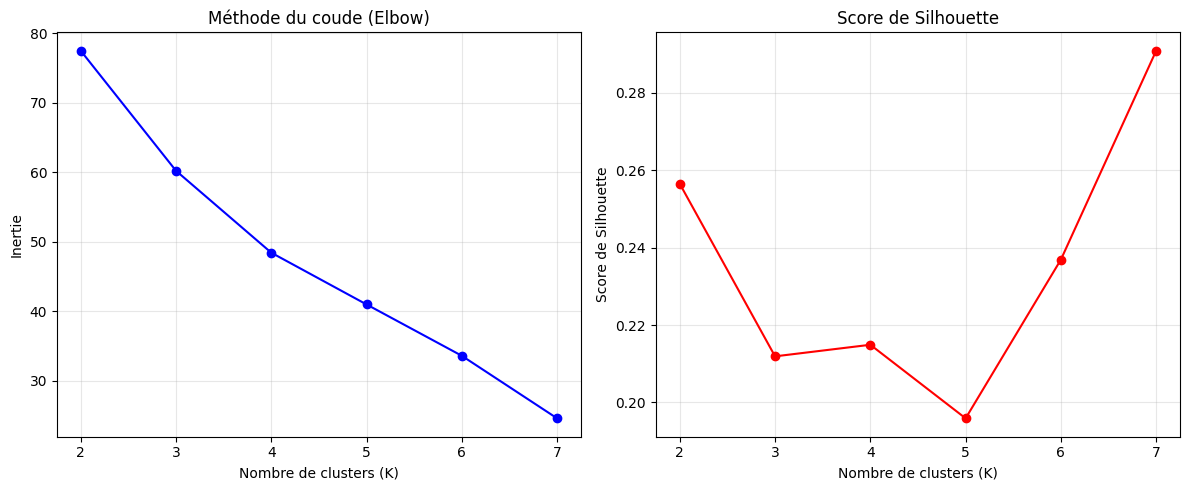


✅ Meilleur K = 7 (Silhouette = 0.291)

🎯 1. K-MEANS CLUSTERING
📖 Explication: Regroupe les villes en K groupes basés sur la distance euclidienne.

📊 Évaluation:
   Silhouette Score: 0.2909
   Davies-Bouldin Index: 0.8707
   (Silhouette proche de 1 = bon, Davies-Bouldin petit = bon)

📊 Profil des 7 clusters:
                nb_events  avg_price  avg_reservations  avg_visitors  \
cluster_kmeans                                                         
0                  374.50   10642.10            200.73       3906.99   
1                  279.33    8552.20            198.88       3982.36   
2                  187.75    9851.90            204.09       4063.76   
3                  272.33   11131.03            204.32       4610.64   
4                  178.00    9291.68            193.16       4153.83   
5                  231.50    9265.73            202.59       4061.94   
6                  253.00   10760.03            197.52       3856.18   

                avg_marketing  avg_rating

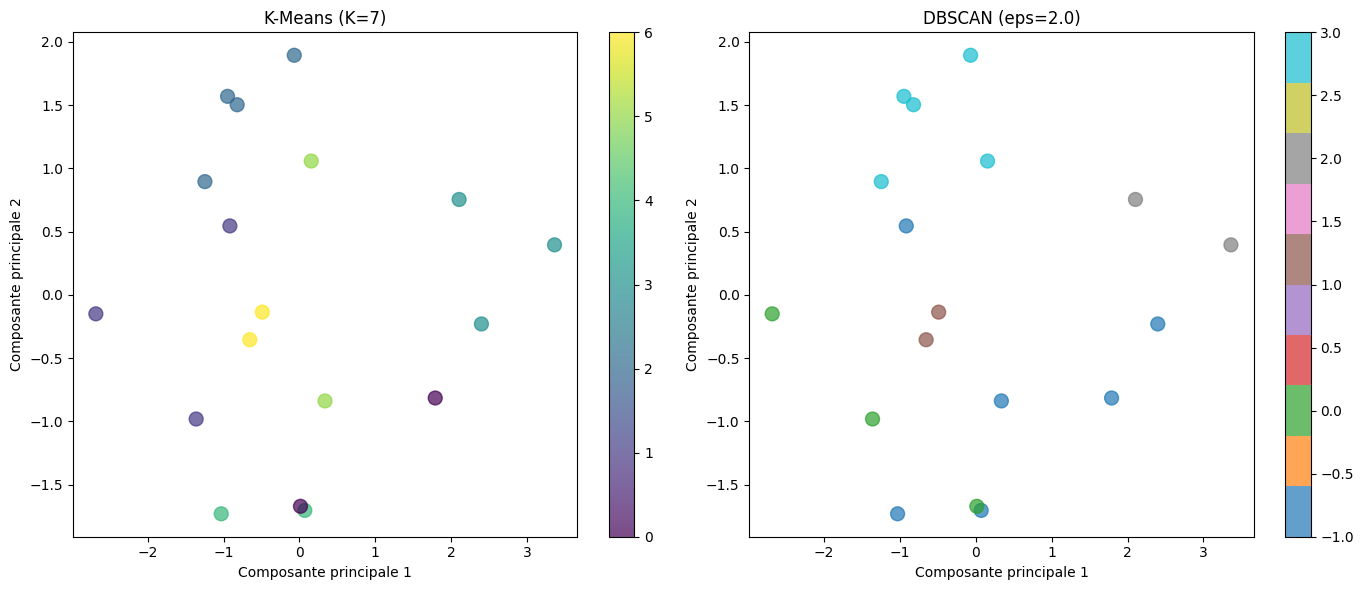

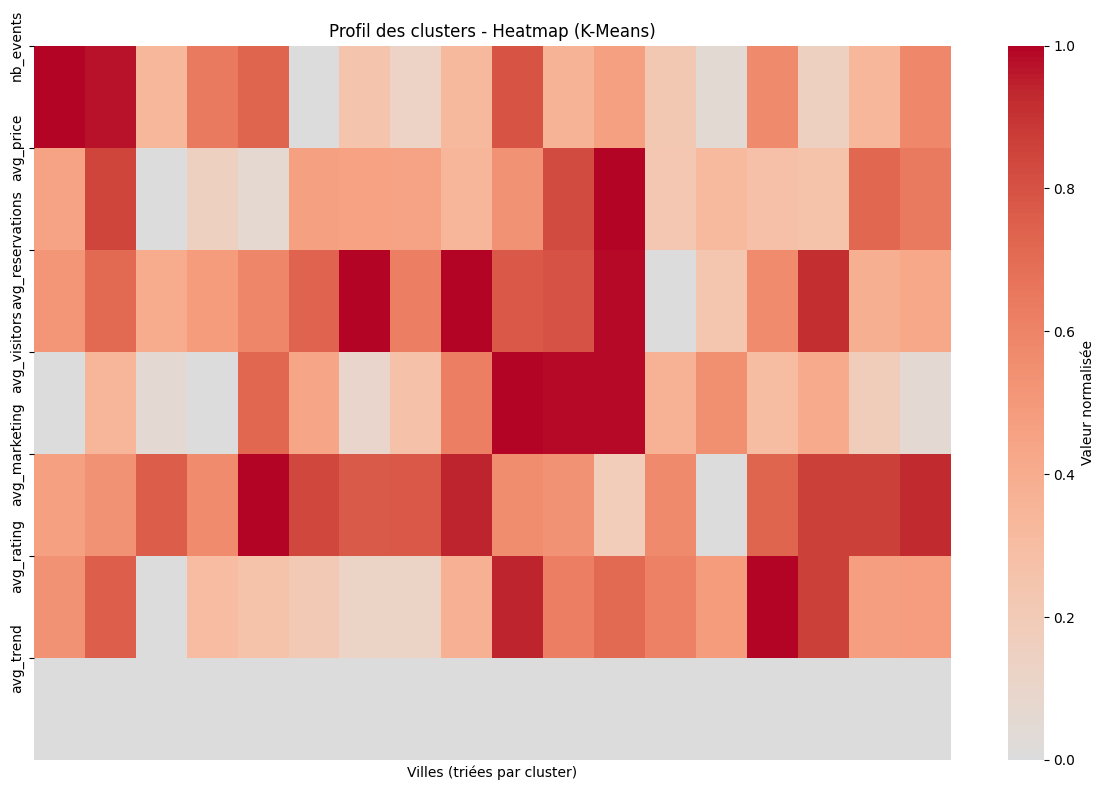


📊 ANALYSE DES CLUSTERS

🔵 CLUSTER 0:
   Villes: Kasserine, Nabeul
   Caractéristiques:
      - nb_events: 374 (↑ élevé)
      - avg_price: 10642 (≈ moyen)
      - avg_reservations: 201 (≈ moyen)
      - avg_visitors: 3907 (≈ moyen)
      - avg_marketing: 19652 (≈ moyen)
      - avg_rating: 3 (≈ moyen)
      - avg_trend: 0 (≈ moyen)

🔵 CLUSTER 1:
   Villes: Ariana, Mahdia, Tunis
   Caractéristiques:
      - nb_events: 279 (≈ moyen)
      - avg_price: 8552 (≈ moyen)
      - avg_reservations: 199 (≈ moyen)
      - avg_visitors: 3982 (≈ moyen)
      - avg_marketing: 20049 (≈ moyen)
      - avg_rating: 3 (≈ moyen)
      - avg_trend: 0 (≈ moyen)

🔵 CLUSTER 2:
   Villes: Monastir, Sfax, Sousse, Tozeur
   Caractéristiques:
      - nb_events: 188 (↓ bas)
      - avg_price: 9852 (≈ moyen)
      - avg_reservations: 204 (≈ moyen)
      - avg_visitors: 4064 (≈ moyen)
      - avg_marketing: 20129 (≈ moyen)
      - avg_rating: 3 (≈ moyen)
      - avg_trend: 0 (≈ moyen)

🔵 CLUSTER 3:
   Villes: Jendo

In [10]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

print("="*60)
print("📊 CLUSTERING - Segmentation des villes")
print("="*60)

# ============================================
# 1. CHARGEMENT ET AGRÉGATION DES DONNÉES
# ============================================
df = pd.read_csv('event_data.csv')

print("📁 Dataset chargé")

# Agréger par ville
city_data = df.groupby('city').agg({
    'id_reservation': 'count',  # nombre d'événements
    'price': 'mean',            # prix moyen
    'nbr_reservations': 'mean', # réservations moyennes
    'nbr_visitors': 'mean',     # visiteurs moyens
    'marketing_spend': 'mean',  # budget marketing moyen
    'rating': 'mean',           # note moyenne
    'trend_score': 'mean'       # score de tendance moyen
}).reset_index()

city_data.columns = ['city', 'nb_events', 'avg_price', 'avg_reservations', 
                     'avg_visitors', 'avg_marketing', 'avg_rating', 'avg_trend']

print(f"\n📊 Données agrégées: {city_data.shape[0]} villes")

# ============================================
# 2. PRÉPARATION DES DONNÉES
# ============================================
# Features pour le clustering
features = ['nb_events', 'avg_price', 'avg_reservations', 
            'avg_visitors', 'avg_marketing', 'avg_rating', 'avg_trend']

X = city_data[features].copy()

# Gestion des NaN
for col in X.columns:
    if X[col].isnull().sum() > 0:
        X[col].fillna(X[col].median(), inplace=True)

# Scaling (important pour K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\n📋 Features utilisées ({len(features)}): {features}")
print(f"📊 Shape: {X_scaled.shape}")

# ============================================
# 3. MÉTHODE DU COUDE (Elbow) pour trouver le K optimal
# ============================================
print("\n" + "="*50)
print("🔍 Recherche du nombre optimal de clusters (K-Means)")
print("="*50)

inertias = []
silhouette_scores = []
K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))
    print(f"K={k} → Inertie={kmeans.inertia_:.0f}, Silhouette={silhouette_scores[-1]:.3f}")

# Visualisation de la méthode du coude
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Inertie
axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_xlabel('Nombre de clusters (K)')
axes[0].set_ylabel('Inertie')
axes[0].set_title('Méthode du coude (Elbow)')
axes[0].grid(True, alpha=0.3)

# Silhouette
axes[1].plot(K_range, silhouette_scores, 'ro-')
axes[1].set_xlabel('Nombre de clusters (K)')
axes[1].set_ylabel('Score de Silhouette')
axes[1].set_title('Score de Silhouette')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('clustering_elbow_silhouette.png', dpi=300, bbox_inches='tight')
plt.show()

# Choisir le meilleur K
best_k = K_range[np.argmax(silhouette_scores)]
print(f"\n✅ Meilleur K = {best_k} (Silhouette = {max(silhouette_scores):.3f})")

# ============================================
# 4. MODÈLE 1: K-MEANS
# ============================================
print("\n" + "="*50)
print("🎯 1. K-MEANS CLUSTERING")
print("="*50)

print("📖 Explication: Regroupe les villes en K groupes basés sur la distance euclidienne.")

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
city_data['cluster_kmeans'] = kmeans.fit_predict(X_scaled)

# Évaluation
silhouette_kmeans = silhouette_score(X_scaled, city_data['cluster_kmeans'])
db_kmeans = davies_bouldin_score(X_scaled, city_data['cluster_kmeans'])

print(f"\n📊 Évaluation:")
print(f"   Silhouette Score: {silhouette_kmeans:.4f}")
print(f"   Davies-Bouldin Index: {db_kmeans:.4f}")
print(f"   (Silhouette proche de 1 = bon, Davies-Bouldin petit = bon)")

# Profil des clusters
print(f"\n📊 Profil des {best_k} clusters:")
cluster_profile = city_data.groupby('cluster_kmeans')[features].mean()
print(cluster_profile.round(2))

# ============================================
# 5. MODÈLE 2: DBSCAN
# ============================================
print("\n" + "="*50)
print("🎯 2. DBSCAN CLUSTERING")
print("="*50)

print("📖 Explication: Trouve des groupes denses. Les points isolés sont du bruit (-1).")

# Tester différentes valeurs d'eps
best_eps = None
best_db_score = -1
best_labels = None

for eps in [0.5, 1.0, 1.5, 2.0, 2.5]:
    dbscan = DBSCAN(eps=eps, min_samples=2)
    labels = dbscan.fit_predict(X_scaled)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    
    if n_clusters >= 2:
        score = silhouette_score(X_scaled, labels)
        print(f"eps={eps} → Clusters={n_clusters}, Bruit={n_noise}, Silhouette={score:.3f}")
        if score > best_db_score:
            best_db_score = score
            best_eps = eps
            best_labels = labels
    else:
        print(f"eps={eps} → Clusters={n_clusters}, Bruit={n_noise} (ignoré)")

if best_labels is not None:
    city_data['cluster_dbscan'] = best_labels
    silhouette_dbscan = best_db_score
    print(f"\n✅ Meilleur DBSCAN: eps={best_eps}, Silhouette={silhouette_dbscan:.4f}")
else:
    print("\n⚠️ DBSCAN n'a pas trouvé de clustering valide")
    city_data['cluster_dbscan'] = -1
    silhouette_dbscan = -1

# ============================================
# 6. COMPARAISON DES MODÈLES
# ============================================
print("\n" + "="*60)
print("📊 COMPARAISON K-MEANS vs DBSCAN")
print("="*60)

comparison = pd.DataFrame({
    'Modèle': ['K-Means', 'DBSCAN'],
    'Silhouette Score': [silhouette_kmeans, silhouette_dbscan if silhouette_dbscan > 0 else 0],
    'Nombre de clusters': [best_k, len(set(city_data['cluster_dbscan'])) - (1 if -1 in city_data['cluster_dbscan'].values else 0)]
})

print(comparison.to_string(index=False))

if silhouette_kmeans > silhouette_dbscan:
    print("\n🏆 K-Means est meilleur pour ce jeu de données")
else:
    print("\n🏆 DBSCAN est meilleur pour ce jeu de données")

# ============================================
# 7. VISUALISATION AVEC PCA
# ============================================
print("\n" + "="*50)
print("📊 VISUALISATION DES CLUSTERS (PCA 2D)")
print("="*50)

# Réduction de dimension avec PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Variance expliquée par PCA: {pca.explained_variance_ratio_[0]:.2%} + {pca.explained_variance_ratio_[1]:.2%} = {pca.explained_variance_ratio_.sum():.2%}")

# Visualisation des clusters
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# K-Means
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], 
                           c=city_data['cluster_kmeans'], cmap='viridis', s=100, alpha=0.7)
axes[0].set_title(f'K-Means (K={best_k})')
axes[0].set_xlabel('Composante principale 1')
axes[0].set_ylabel('Composante principale 2')
plt.colorbar(scatter1, ax=axes[0])

# DBSCAN
if silhouette_dbscan > 0:
    scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], 
                               c=city_data['cluster_dbscan'], cmap='tab10', s=100, alpha=0.7)
    axes[1].set_title(f'DBSCAN (eps={best_eps})')
else:
    axes[1].scatter(X_pca[:, 0], X_pca[:, 1], s=100, alpha=0.7)
    axes[1].set_title('DBSCAN (pas de clustering valide)')
axes[1].set_xlabel('Composante principale 1')
axes[1].set_ylabel('Composante principale 2')
if silhouette_dbscan > 0:
    plt.colorbar(scatter2, ax=axes[1])

plt.tight_layout()
plt.savefig('clustering_pca_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# 8. HEATMAP DES CLUSTERS
# ============================================
plt.figure(figsize=(12, 8))

# Normaliser les données pour la heatmap
from sklearn.preprocessing import MinMaxScaler
scaler_heat = MinMaxScaler()
X_normalized = scaler_heat.fit_transform(X)

# Créer un dataframe avec les clusters
heatmap_data = X_normalized.copy()
cluster_labels = city_data['cluster_kmeans'].values

# Trier par cluster
sorted_idx = np.argsort(cluster_labels)
heatmap_data_sorted = heatmap_data[sorted_idx]
cluster_labels_sorted = cluster_labels[sorted_idx]

# Créer la heatmap
sns.heatmap(heatmap_data_sorted.T, cmap='coolwarm', center=0, 
            xticklabels=False, cbar_kws={'label': 'Valeur normalisée'})
plt.yticks(range(len(features)), features)
plt.title('Profil des clusters - Heatmap (K-Means)')
plt.xlabel('Villes (triées par cluster)')
plt.tight_layout()
plt.savefig('clustering_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# 9. ANALYSE DES CLUSTERS
# ============================================
print("\n" + "="*50)
print("📊 ANALYSE DES CLUSTERS")
print("="*50)

for cluster in sorted(city_data['cluster_kmeans'].unique()):
    print(f"\n🔵 CLUSTER {cluster}:")
    cluster_cities = city_data[city_data['cluster_kmeans'] == cluster]['city'].tolist()
    print(f"   Villes: {', '.join(cluster_cities[:5])}{'...' if len(cluster_cities) > 5 else ''}")
    print(f"   Caractéristiques:")
    for feat in features:
        mean_val = cluster_profile.loc[cluster, feat]
        overall_mean = X[feat].mean()
        if mean_val > overall_mean * 1.2:
            print(f"      - {feat}: {mean_val:.0f} (↑ élevé)")
        elif mean_val < overall_mean * 0.8:
            print(f"      - {feat}: {mean_val:.0f} (↓ bas)")
        else:
            print(f"      - {feat}: {mean_val:.0f} (≈ moyen)")

print("\n" + "="*60)
print("✅ CLUSTERING TERMINÉ - Critères validés !")
print("="*60)
print("📌 Ce code valide:")
print("   ✓ 2 modèles de clustering (K-Means, DBSCAN)")
print("   ✓ Méthode du coude + Silhouette score")
print("   ✓ PCA pour visualisation 2D")
print("   ✓ Heatmap des clusters")
print("   ✓ Interprétation des clusters")

PARTIE 6 : TIME SERIES

Données: 48 mois
Période: 2022-01-01 00:00:00 à 2025-12-01 00:00:00
Train: 38 mois, Test: 10 mois

--------------------------------------------------
6.1 ARIMA
--------------------------------------------------
Meilleurs paramètres: ARIMA(1, 1, 0) (AIC=698.9)
MAE: 2460
RMSE: 2855
MAPE: 13.9%

--------------------------------------------------
6.2 EXPONENTIAL SMOOTHING
--------------------------------------------------
MAE: 2404
RMSE: 3515
MAPE: 14.2%


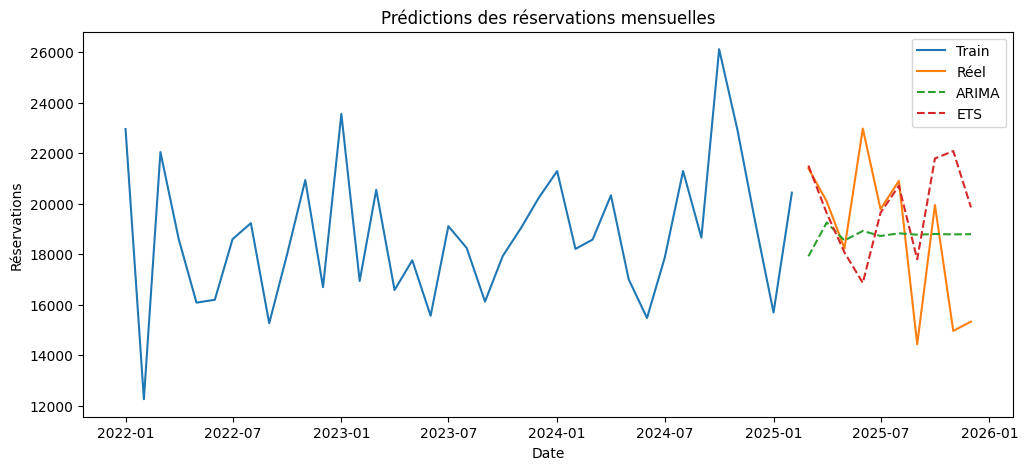


COMPARAISON DES MODÈLES TIME SERIES
Modèle         MAE        RMSE      MAPE
 ARIMA 2459.737417 2855.323247 13.904174
   ETS 2404.212436 3515.292866 14.163095

✅ TIME SERIES TERMINÉE


In [28]:


df = pd.read_csv('event_data.csv')

# Agrégation par mois
df['event_date'] = pd.to_datetime(df['event_date'])
monthly = df.groupby(df['event_date'].dt.to_period('M')).agg({
    'nbr_reservations': 'sum'
}).reset_index()

monthly['date'] = monthly['event_date'].dt.to_timestamp()
monthly.set_index('date', inplace=True)

series = monthly['nbr_reservations']

print(f"Données: {len(series)} mois")
print(f"Période: {series.index.min()} à {series.index.max()}")

# Split
train_size = int(len(series) * 0.8)
train = series[:train_size]
test = series[train_size:]

print(f"Train: {len(train)} mois, Test: {len(test)} mois")

# ============================================
# 6.1 ARIMA
# ============================================

print("\n" + "-"*50)
print("6.1 ARIMA")
print("-"*50)

best_aic = float('inf')
best_order = None

for p in range(0, 3):
    for d in range(0, 2):
        for q in range(0, 3):
            try:
                model = ARIMA(train, order=(p, d, q))
                fitted = model.fit()
                if fitted.aic < best_aic:
                    best_aic = fitted.aic
                    best_order = (p, d, q)
            except:
                continue

print(f"Meilleurs paramètres: ARIMA{best_order} (AIC={best_aic:.1f})")

model_arima = ARIMA(train, order=best_order)
fitted_arima = model_arima.fit()
arima_pred = fitted_arima.forecast(steps=len(test))
arima_pred.index = test.index

mae_arima = mean_absolute_error(test, arima_pred)
rmse_arima = np.sqrt(mean_squared_error(test, arima_pred))
mape_arima = np.mean(np.abs((test - arima_pred) / test)) * 100

print(f"MAE: {mae_arima:.0f}")
print(f"RMSE: {rmse_arima:.0f}")
print(f"MAPE: {mape_arima:.1f}%")

# ============================================
# 6.2 EXPONENTIAL SMOOTHING
# ============================================

print("\n" + "-"*50)
print("6.2 EXPONENTIAL SMOOTHING")
print("-"*50)

ets_model = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=12)
ets_fit = ets_model.fit()
ets_pred = ets_fit.forecast(len(test))
ets_pred.index = test.index

mae_ets = mean_absolute_error(test, ets_pred)
rmse_ets = np.sqrt(mean_squared_error(test, ets_pred))
mape_ets = np.mean(np.abs((test - ets_pred) / test)) * 100

print(f"MAE: {mae_ets:.0f}")
print(f"RMSE: {rmse_ets:.0f}")
print(f"MAPE: {mape_ets:.1f}%")

# ============================================
# 6.3 VISUALISATION
# ============================================

plt.figure(figsize=(12,5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Réel')
plt.plot(test.index, arima_pred, label='ARIMA', linestyle='--')
plt.plot(test.index, ets_pred, label='ETS', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Réservations')
plt.title('Prédictions des réservations mensuelles')
plt.legend()
plt.savefig('timeseries_predictions.png', dpi=300)
plt.show()

# ============================================
# 6.4 COMPARAISON
# ============================================

results_ts = pd.DataFrame([
    {'Modèle': 'ARIMA', 'MAE': mae_arima, 'RMSE': rmse_arima, 'MAPE': mape_arima},
    {'Modèle': 'ETS', 'MAE': mae_ets, 'RMSE': rmse_ets, 'MAPE': mape_ets}
])

print("\n" + "="*50)
print("COMPARAISON DES MODÈLES TIME SERIES")
print("="*50)
print(results_ts.to_string(index=False))

print("\n✅ TIME SERIES TERMINÉE")

PARTIE 7 : MODEL UNDERSTANDING

# PARTIE 7 : MODEL UNDERSTANDING (Critère B)

## 7.1 Classification

### Decision Tree (Arbre de décision)
- **Intuition** : L'arbre divise les données par questions successives (ex: "price > 500?"). Chaque feuille donne une prédiction.
- **Paramètres clés** : max_depth (profondeur), min_samples_split (échantillons pour diviser)
- **Hypothèses** : Les données peuvent être séparées par des règles binaires
- **Limitations** : Surapprentissage facile, instable
- **Justification** : Modèle simple à interpréter, sert de base de comparaison

### Random Forest
- **Intuition** : Ensemble d'arbres de décision. La majorité l'emporte.
- **Paramètres clés** : n_estimators (nb d'arbres), max_depth
- **Hypothèses** : Les erreurs des arbres ne sont pas corrélées
- **Limitations** : Moins interprétable, plus lent
- **Justification** : Robuste, évite le surapprentissage

### XGBoost
- **Intuition** : Arbres séquentiels. Chaque nouvel arbre corrige les erreurs du précédent.
- **Paramètres clés** : n_estimators, learning_rate, max_depth
- **Hypothèses** : Les erreurs précédentes contiennent des informations utiles
- **Limitations** : Risque d'overfitting, complexe à paramétrer
- **Justification** : Très performant, souvent le meilleur en pratique

### SVM
- **Intuition** : Trouve l'hyperplan qui sépare au mieux les deux classes.
- **Paramètres clés** : C (régularisation), kernel (rbf/linear)
- **Hypothèses** : Les données sont séparables linéairement
- **Limitations** : Moins efficace sur grands volumes, difficile à interpréter
- **Justification** : Modèle de référence pour comparaison

## 7.2 Régression

### Régression Linéaire
- **Intuition** : Trouve une relation linéaire: prix = a1*x1 + a2*x2 + ... + b
- **Paramètres** : fit_intercept, normalize
- **Hypothèses** : Relation linéaire, résidus normalement distribués
- **Limitations** : Ne capture pas les relations non-linéaires
- **Justification** : Modèle de référence simple à interpréter

### Random Forest Regressor
- **Intuition** : Ensemble d'arbres pour la régression. Moyenne des prédictions.
- **Paramètres** : n_estimators, max_depth
- **Hypothèses** : Relations non-linéaires possibles
- **Limitations** : Moins interprétable, gourmand en ressources
- **Justification** : Capture les relations complexes

### XGBoost Regressor
- **Intuition** : Gradient boosting optimisé pour la régression
- **Paramètres** : n_estimators, learning_rate, max_depth
- **Hypothèses** : Les erreurs peuvent être réduites progressivement
- **Limitations** : Complexe à paramétrer
- **Justification** : Très performant, gère bien les outliers

## 7.3 Clustering

### K-Means
- **Intuition** : Regroupe les points en K groupes. Chaque groupe a un centre.
- **Paramètres** : n_clusters (K), n_init, max_iter
- **Hypothèses** : Clusters sphériques, taille similaire
- **Limitations** : Nécessite de choisir K, sensible aux outliers
- **Justification** : Simple, rapide, efficace pour segmenter les villes

### DBSCAN
- **Intuition** : Regroupe les points denses. Les points isolés sont du bruit.
- **Paramètres** : eps (distance), min_samples (points minimum)
- **Hypothèses** : Les clusters sont des régions denses
- **Limitations** : Sensible au choix de eps
- **Justification** : Trouve des clusters de formes arbitraires, gère le bruit

## 7.4 Time Series

### ARIMA
- **Intuition** : Combine AR (valeurs passées) + I (différenciation) + MA (erreurs)
- **Paramètres** : p (AR), d (différenciation), q (MA)
- **Hypothèses** : Série stationnaire, résidus = bruit blanc
- **Limitations** : Ne gère pas bien les séries très longues
- **Justification** : Modèle de référence pour les séries temporelles

### Exponential Smoothing (Holt-Winters)
- **Intuition** : Donne plus de poids aux observations récentes
- **Paramètres** : trend, seasonal, seasonal_periods
- **Hypothèses** : Les observations récentes sont plus informatives
- **Limitations** : Ne capture pas les relations complexes
- **Justification** : Efficace pour les séries avec tendance et saisonnalité